In [3]:
import os
import warnings
import matplotlib.pyplot as plt
import pandas as pd

# 🛠️ 環境防線：全域忽略警告、解鎖中文字型與負號正常顯示
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # Windows 微軟正黑體
plt.rcParams['axes.unicode_minus'] = False                # 確保負號正常顯示

# 1. 讀取第二階段留下的完全填答黃金資料集
processed_data_path = '../data/processed/02_core_variables_processed.csv'
df_processed = pd.read_csv(processed_data_path)

print(f"📦 成功從前一階段載入「完全填答黃金樣本池」：{df_processed.shape[0]} 筆")
print("-" * 75)

# 2. 建立二元涉入標籤 (0 = 未涉入, 1 = 有涉入)
# 級分 1.0 代表 0 次（未涉入），級分 2.0~6.0 代表 1 次以上（有涉入）
df_processed['Cig_User'] = (df_processed['CurrentCigaretteUse'] >= 2.0).astype(int)
df_processed['Alc_User'] = (df_processed['EverAlcoholUse'] >= 2.0).astype(int)
df_processed['Mj_User'] = (df_processed['CurrentMarijuaUse'] >= 2.0).astype(int)

# 3. 定義自訂函數，透過二元組合將學生精準分流至 8 個互斥組別
def assign_substance_group(row):
    cig = row['Cig_User']
    alc = row['Alc_User']
    mj = row['Mj_User']
    
    if cig == 0 and alc == 0 and mj == 0:
        return "G1: 完全清白組 (None)"
    elif cig == 1 and alc == 0 and mj == 0:
        return "G2: 單獨吸菸組 (Cig Only)"
    elif cig == 0 and alc == 1 and mj == 0:
        return "G3: 單獨飲酒組 (Alc Only)"
    elif cig == 0 and alc == 0 and mj == 1:
        return "G4: 單獨大麻組 (Mj Only)"
    elif cig == 1 and alc == 1 and mj == 0:
        return "G5: 菸酒共用組 (Cig + Alc)"
    elif cig == 1 and alc == 0 and mj == 1:
        return "G6: 菸大麻共用組 (Cig + Mj)"
    elif cig == 0 and alc == 1 and mj == 1:
        return "G7: 酒大麻共用組 (Alc + Mj)"
    elif cig == 1 and alc == 1 and mj == 1:
        return "G8: 三者全面涉入組 (All Three)"

# 4. 發動分流映射，為每位學生貼上唯一的群體標籤
df_processed['Substance_Group'] = df_processed.apply(assign_substance_group, axis=1)

# 5. 統計這 8 個組別的真實人數與比例分佈
group_counts = df_processed['Substance_Group'].value_counts().sort_index()
group_proportions = (df_processed['Substance_Group'].value_counts(normalize=True).sort_index() * 100).round(2)

# 6. 彙整成推論統計階段的起手點收報告表格
group_summary_df = pd.DataFrame({
    '群體人數 (N)': group_counts,
    '佔全體比例 (%)': group_proportions.astype(str) + '%'
})

print("🎯 【8 大互斥物質使用群體：樣本規模點收表】")
print("-" * 65)
display(group_summary_df)
print("=" * 75)

📦 成功從前一階段載入「完全填答黃金樣本池」：12093 筆
---------------------------------------------------------------------------
🎯 【8 大互斥物質使用群體：樣本規模點收表】
-----------------------------------------------------------------


,群體人數 (N),佔全體比例 (%)
Substance_Group,,
G1: 完全清白組 (None),2850,23.57%
G2: 單獨吸菸組 (Cig Only),52,0.43%
G3: 單獨飲酒組 (Alc Only),5849,48.37%
G4: 單獨大麻組 (Mj Only),46,0.38%
G5: 菸酒共用組 (Cig + Alc),946,7.82%
G6: 菸大麻共用組 (Cig + Mj),17,0.14%
G7: 酒大麻共用組 (Alc + Mj),958,7.92%
G8: 三者全面涉入組 (All Three),1375,11.37%


📊 正在繪製 8 大互斥物質使用群體之人數規模分佈圖...
🎉 長條圖已成功更新並存檔至: ../outputs/figures/03_substance_groups_distribution.png


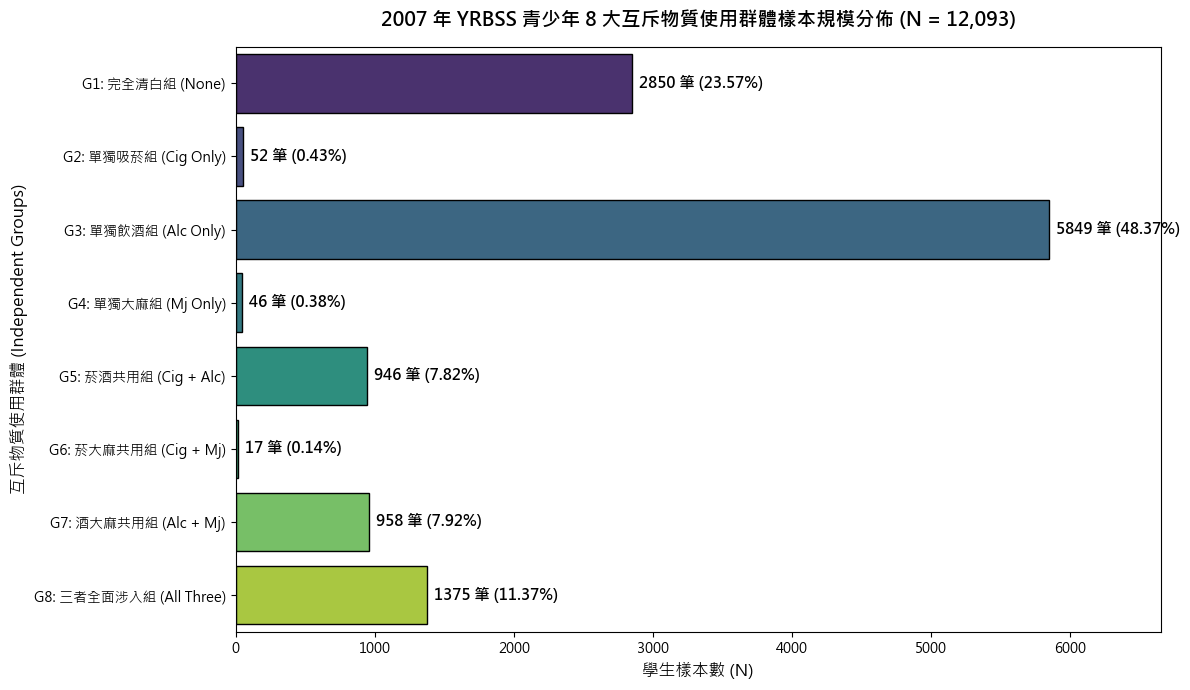

In [4]:
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# 🛠️ 環境防線：確保中文字型與無視警告
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

print("📊 正在繪製 8 大互斥物質使用群體之人數規模分佈圖...")

# 1. 提取剛才算好的數據進行排序與準備
plot_data = df_processed['Substance_Group'].value_counts().reset_index()
plot_data.columns = ['Substance_Group', '群體人數 (N)']
plot_data = plot_data.sort_values('Substance_Group')

# 2. 開啟畫布
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x='群體人數 (N)', 
    y='Substance_Group', 
    data=plot_data, 
    palette='viridis',     # 使用漸層高對比學術配色
    edgecolor='black'
)

# 3. 在長條圖右側優雅地加上「人數 (比例)」雙標籤
total_n = plot_data['群體人數 (N)'].sum()
for p in ax.patches:
    width = p.get_width()
    percentage = (width / total_n * 100).round(2)
    ax.text(
        width + 50, 
        p.get_y() + p.get_height() / 2, 
        f'{int(width)} 筆 ({percentage}%)', 
        ha='left', 
        va='center', 
        fontsize=11, 
        fontweight='bold'
    )

# 4. 圖表外觀與標題優化
plt.title('2007 年 YRBSS 青少年 8 大互斥物質使用群體樣本規模分佈 (N = 12,093)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('學生樣本數 (N)', fontsize=12)
plt.ylabel('互斥物質使用群體 (Independent Groups)', fontsize=12)
plt.xlim(0, plot_data['群體人數 (N)'].max() + 800)  # 留出右側空間給標籤
plt.tight_layout()

# 5. 安全存入指定輸出目錄 (編號 03)
output_fig_path = '../outputs/figures/03_substance_groups_distribution.png'
os.makedirs(os.path.dirname(output_fig_path), exist_ok=True)
plt.savefig(output_fig_path, dpi=300)

print(f"🎉 長條圖已成功更新並存檔至: {output_fig_path}")
plt.show()

In [5]:
print("⚡ 正在合成核心應變數：5 大硬性毒品涉入嚴重度指數 (Hard_Drug_Severity)...")

# 1. 鎖定 5 大硬性毒品欄位
hard_drug_columns = [
    'EverCocaineUse', 
    'EverHeroinUse', 
    'EverInhalantUse', 
    'EverMethamphetamineUse', 
    'EverEcstasyUse'
]

# 2. 發動減 1 轉換並加總 (0 代表完全清白，分數越高涉入越深)
df_processed['Hard_Drug_Severity'] = df_processed[hard_drug_columns].apply(lambda x: x - 1).sum(axis=1)

print("=" * 70)
print("📈 【各群體之硬性毒品涉入嚴重度：敘述統計初步點收】")
print("-" * 70)

# 3. 搶先看 8 大群體在硬性毒品得分上的平均數 (Mean)、標準差 (Std) 與最大值
severity_summary = df_processed.groupby('Substance_Group')['Hard_Drug_Severity'].agg(['count', 'mean', 'std', 'max']).round(4)
severity_summary.columns = ['有效樣本數 (N)', '嚴重度平均數 (Mean)', '標準差 (Std)', '最高得分 (Max)']

display(severity_summary)
print("=" * 70)

⚡ 正在合成核心應變數：5 大硬性毒品涉入嚴重度指數 (Hard_Drug_Severity)...
📈 【各群體之硬性毒品涉入嚴重度：敘述統計初步點收】
----------------------------------------------------------------------


,有效樣本數 (N),嚴重度平均數 (Mean),標準差 (Std),最高得分 (Max)
Substance_Group,,,,
G1: 完全清白組 (None),2850,0.0284,0.2476,5.0
G2: 單獨吸菸組 (Cig Only),52,0.1346,0.7417,5.0
G3: 單獨飲酒組 (Alc Only),5849,0.2679,0.9972,20.0
G4: 單獨大麻組 (Mj Only),46,0.3261,0.9673,6.0
G5: 菸酒共用組 (Cig + Alc),946,1.1427,2.4765,19.0
G6: 菸大麻共用組 (Cig + Mj),17,0.4118,0.8703,3.0
G7: 酒大麻共用組 (Alc + Mj),958,0.8497,2.3467,25.0
G8: 三者全面涉入組 (All Three),1375,3.0051,5.3072,25.0
